<a href="https://colab.research.google.com/github/ottoferrer/patient_data/blob/main/Proyectofinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto del Proyecto y Preguntas de Negocio (Framework Minto)
**Integrantes: Otto Ferrer - Gema Zambrano**

Para alinear el análisis de datos con los objetivos clínicos, utilizamos el principio de la Pirámide de Minto para estructurar nuestra narrativa. Partimos de una situación conocida (datos radiológicos masivos), identificamos una complicación (la dificultad de estratificar riesgos complejos) y planteamos preguntas clave que nuestro análisis resolverá.



*   **Situación:** Contamos con un dataset masivo de radiografías de tórax (CheXpert) enriquecido con datos demográficos, vital para el diagnóstico hospitalario.

*   **Complicación:** Los diagnósticos aislados no revelan el perfil de riesgo integral del paciente ni posibles sesgos demográficos en la atención.


**Preguntas de Negocio a Resolver:**

*   **Perfil de Multimorbilidad:** ¿Cómo evoluciona la complejidad del cuadro clínico (carga patológica) a medida que el paciente envejece, diferenciando por género?

*   **Sesgos Demográficos:** ¿Existen disparidades significativas en la prevalencia de patologías severas (como Neumonía o Edema) condicionadas por el grupo étnico del paciente?

*   **Patrones de Co-ocurrencia:** ¿Qué enfermedades pulmonares tienden a aparecer simultáneamente, sugiriendo síndromes clínicos compuestos?

*   **Gravedad y Soporte Vital:** ¿Es la presencia de dispositivos médicos de soporte un indicador confiable de una alta carga patológica en el paciente?

*   **Análisis de "No Hallazgos":** ¿Qué perfil demográfico presenta la mayor tasa de radiografías sin hallazgos patológicos ("No Finding"), indicando posibles descartes preventivos?

# Configuracion y Carga de Datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# Configuracion profesional: Estilos y manejo de warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("--- 1. CARGA DE DATOS ---")
# 1. Carga del dataset de etiquetas visuales (Hallazgos Clinicos)
url_labels = "https://github.com/ottoferrer/patient_data/raw/main/train_visualCheXbert.csv"
df_labels = pd.read_csv(url_labels)

# 2. Carga del dataset demografico
url_demo = 'https://github.com/ottoferrer/patient_data/raw/main/CHEXPERT%20DEMO.xlsx'
df_demo = pd.read_excel(url_demo, engine='openpyxl')

# --- PRE-PROCESAMIENTO INICIAL ---
# Extraccion de metadatos desde la columna 'Path'
df_labels[['version', 'split', 'Patient_id', 'Study', 'Image']] = df_labels['Path'].str.split('/', expand=True)

# Estandarizacion de nombres de columnas en el demografico para el cruce
df_demo = df_demo.rename(columns={
    'PRIMARY_RACE': 'Race',
    'PATIENT': 'Patient_id',
    'GENDER': 'Sex',
    'AGE_AT_CXR': 'Age',
    'ETHNICITY': 'Ethnicity'
})

# --- INSPECCION Y DIAGNOSTICO ---
print("\n[VISTA PREVIA] Dataset Clinico (Primeras 3 filas):")
display(df_labels.head(3))
print("\n[VISTA PREVIA] Dataset Demografico (Primeras 3 filas):")
display(df_demo.head(3))

print("\n--- DIAGNOSTICO DE CALIDAD DE DATOS (PRE-FUSION) ---")
print("1. Tipos de datos en Demografico:")
df_demo.info()
print("\n2. Revision de Nulos en Variables Criticas (Demografico):")
print(f"   - Nulos en Edad: {df_demo['Age'].isnull().sum()}")
print(f"   - Nulos en Sexo: {df_demo['Sex'].isnull().sum()}")

--- 1. CARGA DE DATOS ---

[VISTA PREVIA] Dataset Clinico (Primeras 3 filas):


,Path,Sex,Age,Frontal/Lateral,AP/PA,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,...,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding,version,split,Patient_id,Study,Image
0,CheXpert-v1.0/train/patient00001/study1/view1_...,Female,68,Frontal,AP,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,CheXpert-v1.0,train,patient00001,study1,view1_frontal.jpg
1,CheXpert-v1.0/train/patient00002/study2/view1_...,Female,87,Frontal,AP,1.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,CheXpert-v1.0,train,patient00002,study2,view1_frontal.jpg
2,CheXpert-v1.0/train/patient00002/study1/view1_...,Female,83,Frontal,AP,1.0,1.0,1.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,CheXpert-v1.0,train,patient00002,study1,view1_frontal.jpg



[VISTA PREVIA] Dataset Demografico (Primeras 3 filas):


,Patient_id,Sex,Age,Race,Ethnicity
0,patient24428,Male,61,White,Non-Hispanic/Non-Latino
1,patient48289,Female,39,Other,Hispanic/Latino
2,patient33856,Female,81,White,Non-Hispanic/Non-Latino



--- DIAGNOSTICO DE CALIDAD DE DATOS (PRE-FUSION) ---
1. Tipos de datos en Demografico:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65401 entries, 0 to 65400
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Patient_id  65401 non-null  object
 1   Sex         65401 non-null  object
 2   Age         65401 non-null  int64 
 3   Race        64860 non-null  object
 4   Ethnicity   65317 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.5+ MB

2. Revision de Nulos en Variables Criticas (Demografico):
   - Nulos en Edad: 0
   - Nulos en Sexo: 0


# Preprocesamiento, Limpieza y Fusión de Datasets
Integramos la información clínica y demográfica mediante el Patient_id. Aplicamos reglas de estandarización para las variables "Raza" y "Etnia". Criterio de Limpieza: Eliminamos los registros que presentan valores nulos (NaN) en Edad o Sexo, ya que son variables estructurales para la segmentación. Sin embargo, preservamos explícitamente los casos con Edad 0, correspondientes a pacientes neonatos, asegurando que no sean tratados erróneamente como datos faltantes.

In [2]:
print("--- 2. PROCESO DE FUSION Y LIMPIEZA ---")

# 1. FUSION DE DATASETS (Left Join)
# Mantenemos todas las imagenes y traemos datos del paciente si existen
df_final = pd.merge(df_labels, df_demo.drop(['Sex', 'Age'], axis=1), on='Patient_id', how='left')

print(f"[MONITOREO] Total de registros fusionados: {len(df_final)}")

# 2. ESTANDARIZACION DE CATEGORICAS (Raza y Etnia)
df_processing = df_final.copy() # Copia de seguridad para trabajar

# Limpieza de Raza
df_processing["race_standardized"] = np.nan
race_clean = df_processing["Race"].str.lower().str.strip()
df_processing.loc[race_clean.str.contains("white|caucasian", na=False), "race_standardized"] = "White"
df_processing.loc[race_clean.str.contains("black|african", na=False), "race_standardized"] = "Black/African American"
df_processing.loc[race_clean.str.contains("asian", na=False), "race_standardized"] = "Asian"
df_processing.loc[race_clean.str.contains("unknown|refused", na=False), "race_standardized"] = "Unknown"
df_processing["race_standardized"].fillna("Other", inplace=True)

# Limpieza de Etnia
df_processing["ethnicity_standardized"] = np.nan
eth_clean = df_processing["Ethnicity"].str.lower().str.strip()
df_processing.loc[eth_clean.str.contains("hispanic|latino", na=False), "ethnicity_standardized"] = "Hispanic/Latino"
df_processing.loc[eth_clean.str.contains("non-hispanic", na=False), "ethnicity_standardized"] = "Non-Hispanic"
df_processing["ethnicity_standardized"].fillna("Unknown", inplace=True)

# 3. FILTRADO DE NULOS CRITICOS (Preservando Bebes)
# Verificamos cuantos nulos reales hay (NaN) vs cuantos tienen edad 0
nulos_reales = df_processing['Age'].isnull().sum()
bebes = len(df_processing[df_processing['Age'] == 0])
print(f"[MONITOREO] Deteccion de casos especiales:")
print(f"   - Nulos reales (NaN) a eliminar: {nulos_reales}")
print(f"   - Pacientes con Edad 0 (a conservar): {bebes}")

# Ejecutamos el dropna SOLO en filas donde Age o Sex son NaN
df_clean = df_processing.dropna(subset=['Age', 'Sex']).copy()

print(f"\n[RESULTADO] Limpieza finalizada. Dataset listo con {len(df_clean)} registros.")

--- 2. PROCESO DE FUSION Y LIMPIEZA ---
[MONITOREO] Total de registros fusionados: 223414
[MONITOREO] Deteccion de casos especiales:
   - Nulos reales (NaN) a eliminar: 0
   - Pacientes con Edad 0 (a conservar): 3

[RESULTADO] Limpieza finalizada. Dataset listo con 223414 registros.


# Creación de Nuevas Métricas y Variables Derivadas
Generamos nuevas métricas para profundizar el análisis:

Índice de Carga Patológica: Suma de hallazgos positivos por paciente. Esta métrica se sustenta en el estudio de Johnston et al. (2019) en el European Journal of Public Health, el cual valida el conteo simple de enfermedades concurrentes como una medida robusta de la carga de morbilidad y complejidad del paciente en entornos de atención primaria.

Grupo de Edad (Age Group): Segmentación de los pacientes en Joven, Adulto y Senior, asegurando la inclusión correcta de neonatos (0 años).

In [3]:
print("--- 3. GENERACION DE METRICAS ---")

# Definicion de columnas de patologias (Excluyendo 'No Finding' y 'Support Devices')
# El 1 indica presencia de enfermedad, el 0 ausencia.
pathology_columns = [
    'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture'
]

# 1. Creacion del Indice de Carga Patologica (Suma horizontal)
df_clean['Indice_Carga_Patologica'] = df_clean[pathology_columns].sum(axis=1)

# 2. Creacion de Grupos de Edad
# Usamos include_lowest=True para que el intervalo incluya el 0 (Bebes)
bins = [0, 30, 60, 110]
labels = ['Joven (0-30)', 'Adulto (30-60)', 'Senior (>60)']
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, include_lowest=True)

# Verificacion visual de las nuevas metricas
print("[VISTA PREVIA] Nuevas variables generadas:")
# Mostramos un ejemplo aleatorio y si hay bebes, los mostramos para verificar
muestra_bebes = df_clean[df_clean['Age'] == 0].head(2)
muestra_general = df_clean.head(3)
display(pd.concat([muestra_bebes, muestra_general])[['Patient_id', 'Age', 'Age_Group', 'Indice_Carga_Patologica']])

--- 3. GENERACION DE METRICAS ---
[VISTA PREVIA] Nuevas variables generadas:


,Patient_id,Age,Age_Group,Indice_Carga_Patologica
223411,patient64538,0,Joven (0-30),4.0
223412,patient64539,0,Joven (0-30),6.0
0,patient00001,68,Senior (>60),0.0
1,patient00002,87,Senior (>60),7.0
2,patient00002,83,Senior (>60),9.0


# Determinación del Porcentaje de Ruido
Cumpliendo con el requisito de calidad de datos, calculamos formalmente el porcentaje de "ruido" del dataset. Definimos ruido como aquellas observaciones que carecen de información completa en variables críticas después del proceso de fusión, lo que las inhabilita para el análisis multivariado robusto.

In [4]:
# Calculo de ruido: Diferencia entre dataset fusionado (raw) y dataset limpio
total_raw = len(df_final)
total_clean = len(df_clean)
filas_ruido = total_raw - total_clean
pct_ruido = (filas_ruido / total_raw) * 100

print(f"--- 4. REPORTE DE CALIDAD (RUIDO) ---")
print(f"Registros Totales (Post-Fusion): {total_raw}")
print(f"Registros Utiles (Limpios):      {total_clean}")
print(f"Registros Descartados (Ruido):   {filas_ruido}")
print(f"Porcentaje de Ruido del Dataset: {pct_ruido:.4f}%")
print("-" * 30)
if pct_ruido == 0:
    print("CONCLUSION: La calidad del cruce es perfecta. No hubo perdida de datos por nulos demograficos.")
else:
    print(f"CONCLUSION: Se perdio el {pct_ruido:.2f}% de los datos debido a falta de informacion demografica.")

--- 4. REPORTE DE CALIDAD (RUIDO) ---
Registros Totales (Post-Fusion): 223414
Registros Utiles (Limpios):      223414
Registros Descartados (Ruido):   0
Porcentaje de Ruido del Dataset: 0.0000%
------------------------------
CONCLUSION: La calidad del cruce es perfecta. No hubo perdida de datos por nulos demograficos.


# Análisis Visual y Respuesta a Preguntas de Negocio
Presentamos los hallazgos visuales alineados con las preguntas de negocio:

Mapa de Calor: Muestra correlaciones numéricas exactas entre patologías para detectar comorbilidades.

Faceted Boxplot: Analiza la distribución de la carga patológica por edad y sexo (filtrando valores desconocidos para mayor claridad).

Gráfico de Barras: Evalúa la relación entre el uso de dispositivos de soporte y la gravedad del paciente, utilizando etiquetas claras (Sí/No).

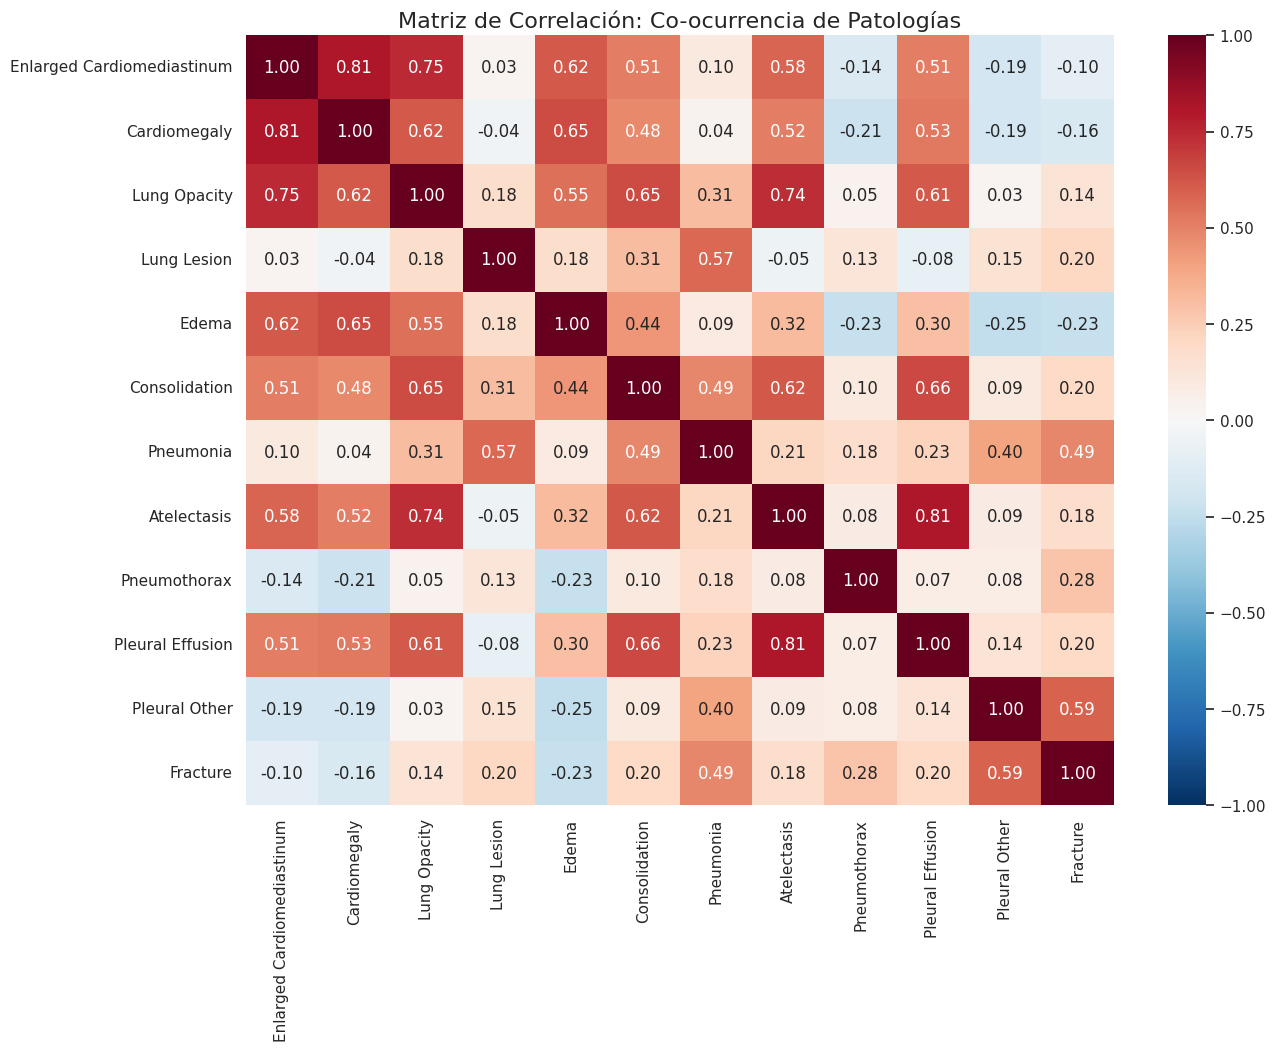

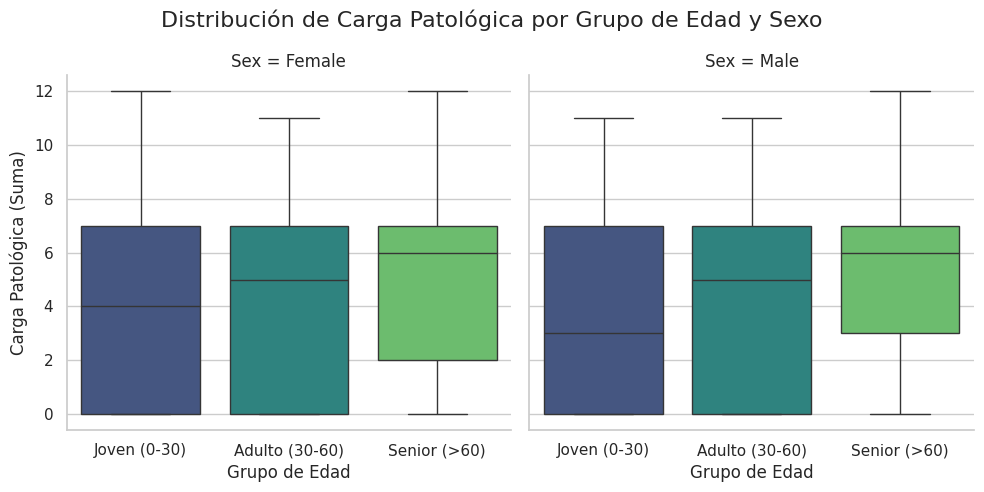

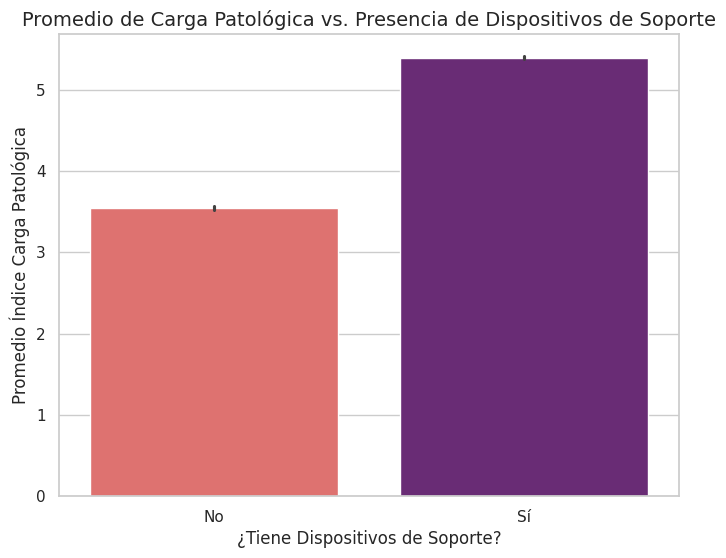

In [5]:
# 1. MAPA DE CALOR DE CORRELACIONES (Con Valores Numericos)
plt.figure(figsize=(14, 10))
# Calculamos la correlacion solo de las columnas de patologias
corr_matrix = df_clean[pathology_columns].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1)
plt.title("Matriz de Correlación: Co-ocurrencia de Patologías", fontsize=16)
plt.show()

# 2. FACETED PLOT - DISTRIBUCION DE CARGA PATOLOGICA
# Filtramos 'Unknown' en Sexo para limpiar el grafico
df_viz = df_clean[df_clean['Sex'] != 'Unknown'].copy()

g = sns.catplot(
    data=df_viz,
    x="Age_Group",
    y="Indice_Carga_Patologica",
    col="Sex",           # Faceta por columna (Sexo)
    kind="box",          # Tipo Boxplot para ver medianas y outliers
    palette="viridis",
    hue="Age_Group",     # Asignamos hue para evitar warnings
    height=5,
    aspect=1
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Distribución de Carga Patológica por Grupo de Edad y Sexo', fontsize=16)
g.set_axis_labels("Grupo de Edad", "Carga Patológica (Suma)")
plt.show()

# 3. GRAFICO DE BARRAS - DISPOSITIVOS DE SOPORTE
plt.figure(figsize=(8, 6))

# Creamos una columna temporal para etiquetas legibles en el eje X
df_viz['Soporte_Label'] = df_viz['Support Devices'].map({0.0: 'No', 1.0: 'Sí'})

sns.barplot(
    data=df_viz,
    x='Soporte_Label',
    y='Indice_Carga_Patologica',
    palette='magma',
    hue='Soporte_Label',
    order=['No', 'Sí']   # Ordenamos explicitamente
)
plt.title("Promedio de Carga Patológica vs. Presencia de Dispositivos de Soporte", fontsize=14)
plt.xlabel("¿Tiene Dispositivos de Soporte?")
plt.ylabel("Promedio Índice Carga Patológica")
plt.show()